In [7]:
QUERY   = "q20"                       # q2 … q21
REPORT  = "cost-report/tpch100-v5"
RUN     = "median"                   # "median" = run có T đo ở giữa, hoặc số run 1, 2, …
SYSTEMS = ["base", "s3", "nfs"]      # base = No BF

In [8]:
import os, re, json, glob, statistics
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from datetime import datetime
%matplotlib inline

fm.fontManager.addfont("./fonts/LinLibertine_R.otf")
plt.rcParams['font.family'] = 'Linux Libertine O'
plt.rcParams['font.serif'] = ['Linux Libertine O']
FONT_SIZE = 15
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['lines.linewidth'] = 0.8

plt.rcParams.update({
    "axes.grid": True, "legend.frameon": False,
    "axes.spines.top": True, "axes.spines.right": True,      # khung 4 cạnh
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 200, "savefig.bbox": "tight",
})
plt.rcParams.update({                 # số mũ trục log (10¹) và ký hiệu toán cũng dùng Libertine thay vì DejaVu Sans
    "mathtext.fontset": "custom", "mathtext.rm": "Linux Libertine O",
    "mathtext.it": "Linux Libertine O", "mathtext.bf": "Linux Libertine O", "axes.unicode_minus": True,
})
neg = lambda s: s.replace("-", "\u2212")   # dấu trừ thật (−) cho các nhãn số tự định dạng
INK, INK2, GRID = "#000000", "#52514e", "#e4e3df"
plt.rcParams.update({"axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                     "grid.color": GRID})
plt.rcParams.update({"text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black", "legend.labelcolor": "black"})  # chữ đen toàn bộ
LABEL = {"base": "No BF", "s3": "BF + S3 shuffle", "nfs": "BF + NFS shuffle"}
COLOR = {"base": "#2a78d6", "s3": "#eb6834", "nfs": "#1baf7a"}
COST_UNIT, COST_SCALE = "¢", 100      # đơn vị chi phí: ("¢", 100) cent, ("m\\$", 1e3) milli-dollar, ("µ\\$", 1e6)
cost_fmt = lambda usd: f"{usd * COST_SCALE:,.2f}{COST_UNIT}"
ROOT  = ".."                         # report.json lưu đường dẫn history/... tính từ thư mục gốc repo
OUT   = os.path.join(REPORT, "stages", QUERY)
os.makedirs(OUT, exist_ok=True)


def tint(c, a=0.45):
    """Màu nhạt hơn của c (trộn với trắng) cho thanh model."""
    r, g, b = to_rgb(c)
    return tuple(x + (1 - x) * (1 - a) for x in (r, g, b))


SHORT_NAMES = False                  # False = giữ nguyên tên stage như trong file pipeline


def short(name):
    """Tên stage hiển thị; SHORT_NAMES=True thì gọn: Step3-join-customer-orders--combine -> 3 join-customer-orders · combine."""
    if not SHORT_NAMES:
        return name
    n = name.replace("--combine", " · combine").replace("--mergebf", " · merge BF").replace("--reduce", " · reduce")
    return re.sub(r"^[Ss]tep(\d+)-", r"\1 ", n)


def wrap_label(name, width=14):
    """Xuống dòng tên stage (giữ nguyên chữ): tách trước '--', rồi ngắt sau dấu '-' khi dòng dài quá width ký tự."""
    lines = []
    for k, seg in enumerate(name.split("--")):
        seg = ("--" if k else "") + seg
        cur = ""
        for tok in re.findall(r"[^-]+-*|-+", seg):
            if cur and len(cur) + len(tok) > width:
                lines.append(cur)
                cur = tok
            else:
                cur += tok
        lines.append(cur)
    return "\n".join(lines)


def xlabels(names):
    return [wrap_label(short(v), XTICK_WRAP) if XTICK_WRAP else short(v) for v in names]


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(OUT, f"{name}.{ext}"))


def load(system, run=RUN):
    """Run được chọn của một hệ: (stages DataFrame theo thứ tự pipeline, totals, folder, nhãn run)."""
    prefix, side = ("s3", "nobf") if system == "base" else (system, "bf")
    paths = sorted(glob.glob(os.path.join(REPORT, QUERY, f"{prefix}-run*", "report.json")),
                   key=lambda p: int(p.split("-run")[-1].split(os.sep)[0]))
    reps = {int(p.split("-run")[-1].split(os.sep)[0]): json.load(open(p))["runs"][side] for p in paths}
    if run == "median":
        T = {i: r["totals"]["T_meas"] for i, r in reps.items()}
        i = min(T, key=lambda k: (T[k] != statistics.median_low(T.values()), k))
    else:
        i = int(run)
    r = reps[i]
    return pd.DataFrame(r["stages"]), r["totals"], r["folder"], f"run {i}/{len(reps)}"


def measured_timeline(folder, st):
    """(start, end) thực đo của từng stage tính từ lúc query bắt đầu; thiếu history thì cộng dồn d_wall."""
    path = os.path.join(ROOT, folder, "cost-stages.jsonl")
    if os.path.exists(path):
        ts = lambda x: datetime.fromisoformat(x).timestamp()
        span = {}
        for line in open(path):
            r = json.loads(line)
            span[r["stage"]] = (min(ts(t["start"]) for t in r["tasks"]), max(ts(t["end"]) for t in r["tasks"]))
        t0 = min(a for a, _ in span.values())
        return [(span[n][0] - t0, span[n][1] - t0) for n in st["stage"]], True
    end = st["meas_d_wall"].cumsum()
    return list(zip(end - st["meas_d_wall"], end)), False


DATA = {s: load(s) for s in SYSTEMS}
for s, (st, tot, folder, tag) in DATA.items():
    pass
    print(f"{LABEL[s]:18} {tag:9} {len(st):2} stages  T đo {tot['T_meas']:6.2f}s model {tot['T_model']:6.2f}s  "
          f"C đo {cost_fmt(tot['C_meas']):>9} model {cost_fmt(tot['C_model']):>9}   {folder}")
print("saving to", OUT)

No BF              run 9/15  21 stages  T đo  35.94s model  30.91s  C đo     7.93¢ model     6.21¢   history/q20/20261002-00291790900998--starling-base
BF + S3 shuffle    run 8/15  25 stages  T đo  10.31s model  11.48s  C đo     1.39¢ model     1.39¢   history/q20/20261002-02571790909833--bloomfaas-s3-bloomfaas
BF + NFS shuffle   run 15/15 25 stages  T đo   9.10s model  10.39s  C đo     1.16¢ model     1.24¢   history/q20/20261002-05271790918859--bloomfaas-nfs-bloomfaas
saving to cost-report/tpch100-v5/stages/q20


## 1. Processing time

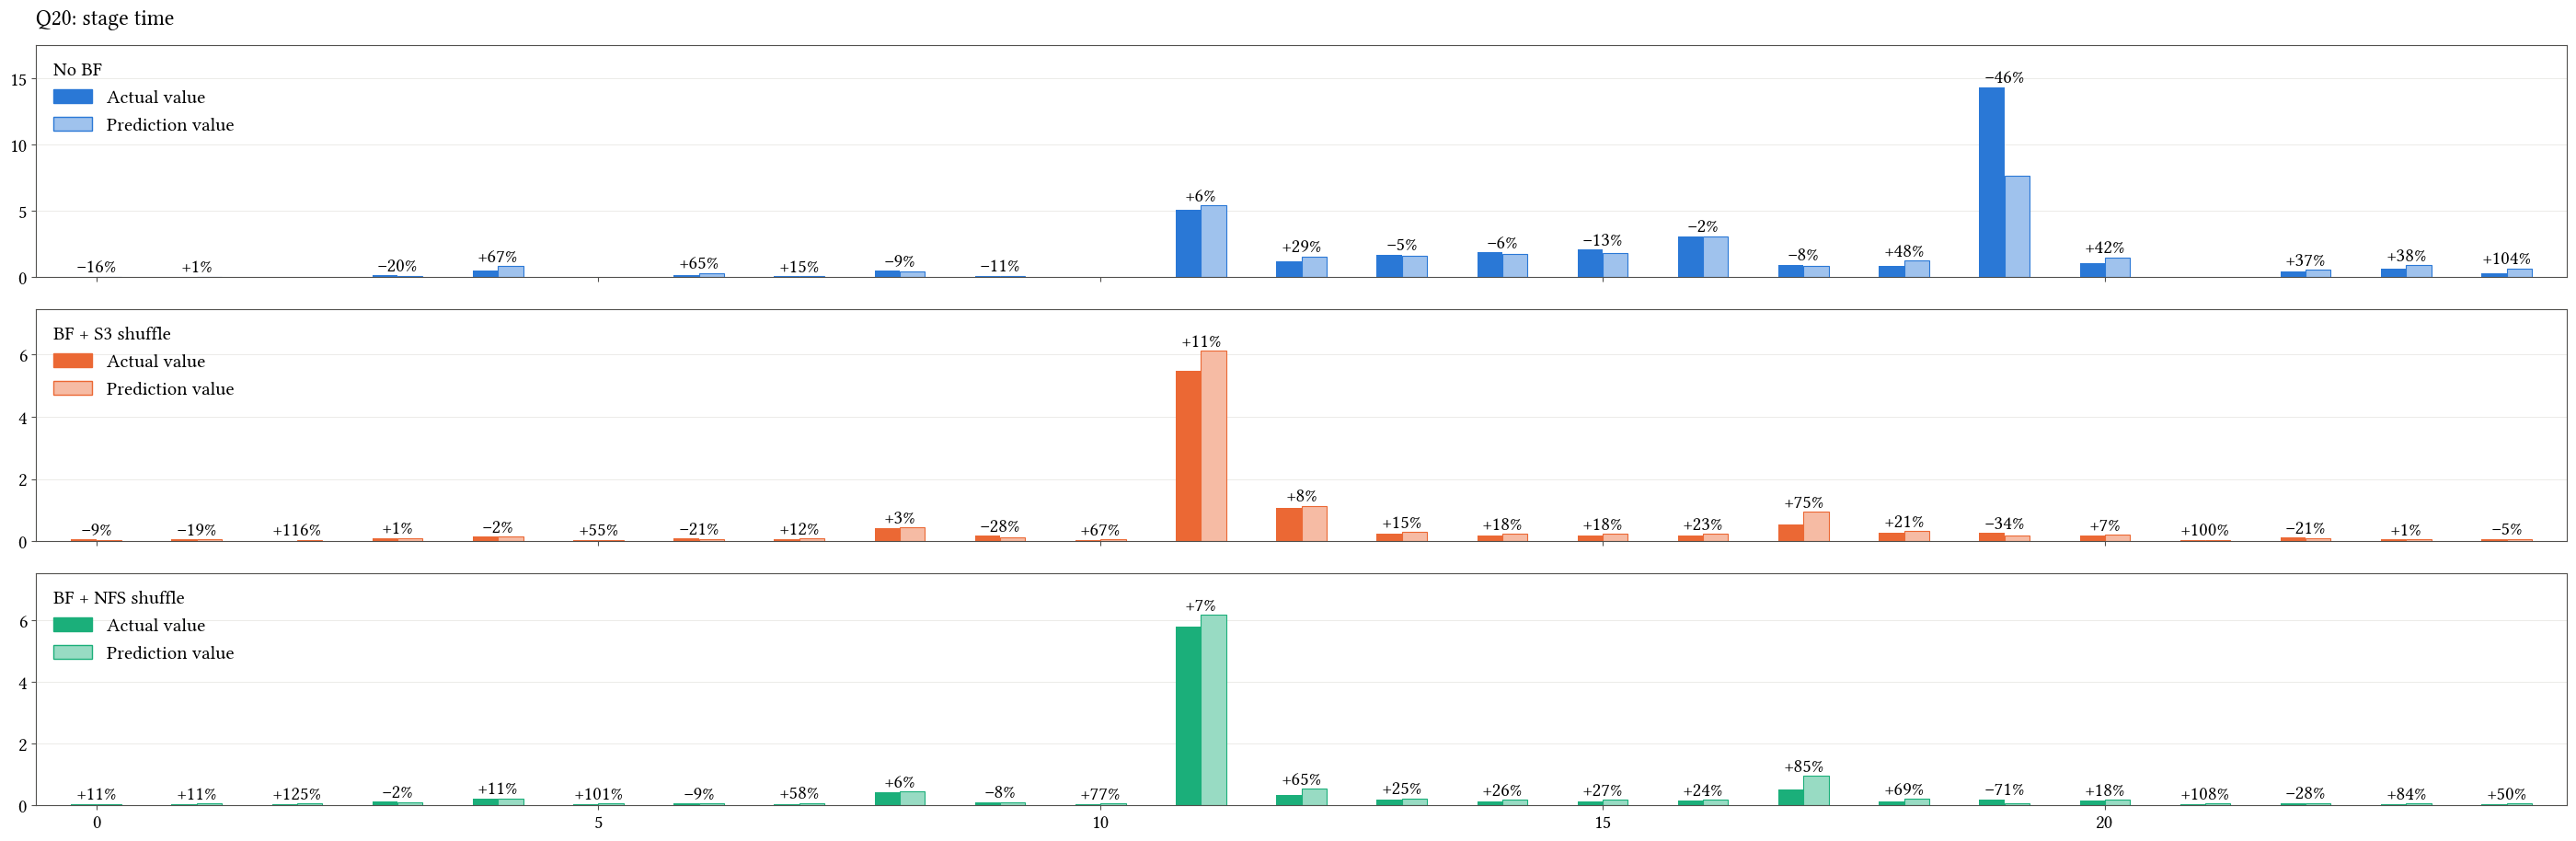

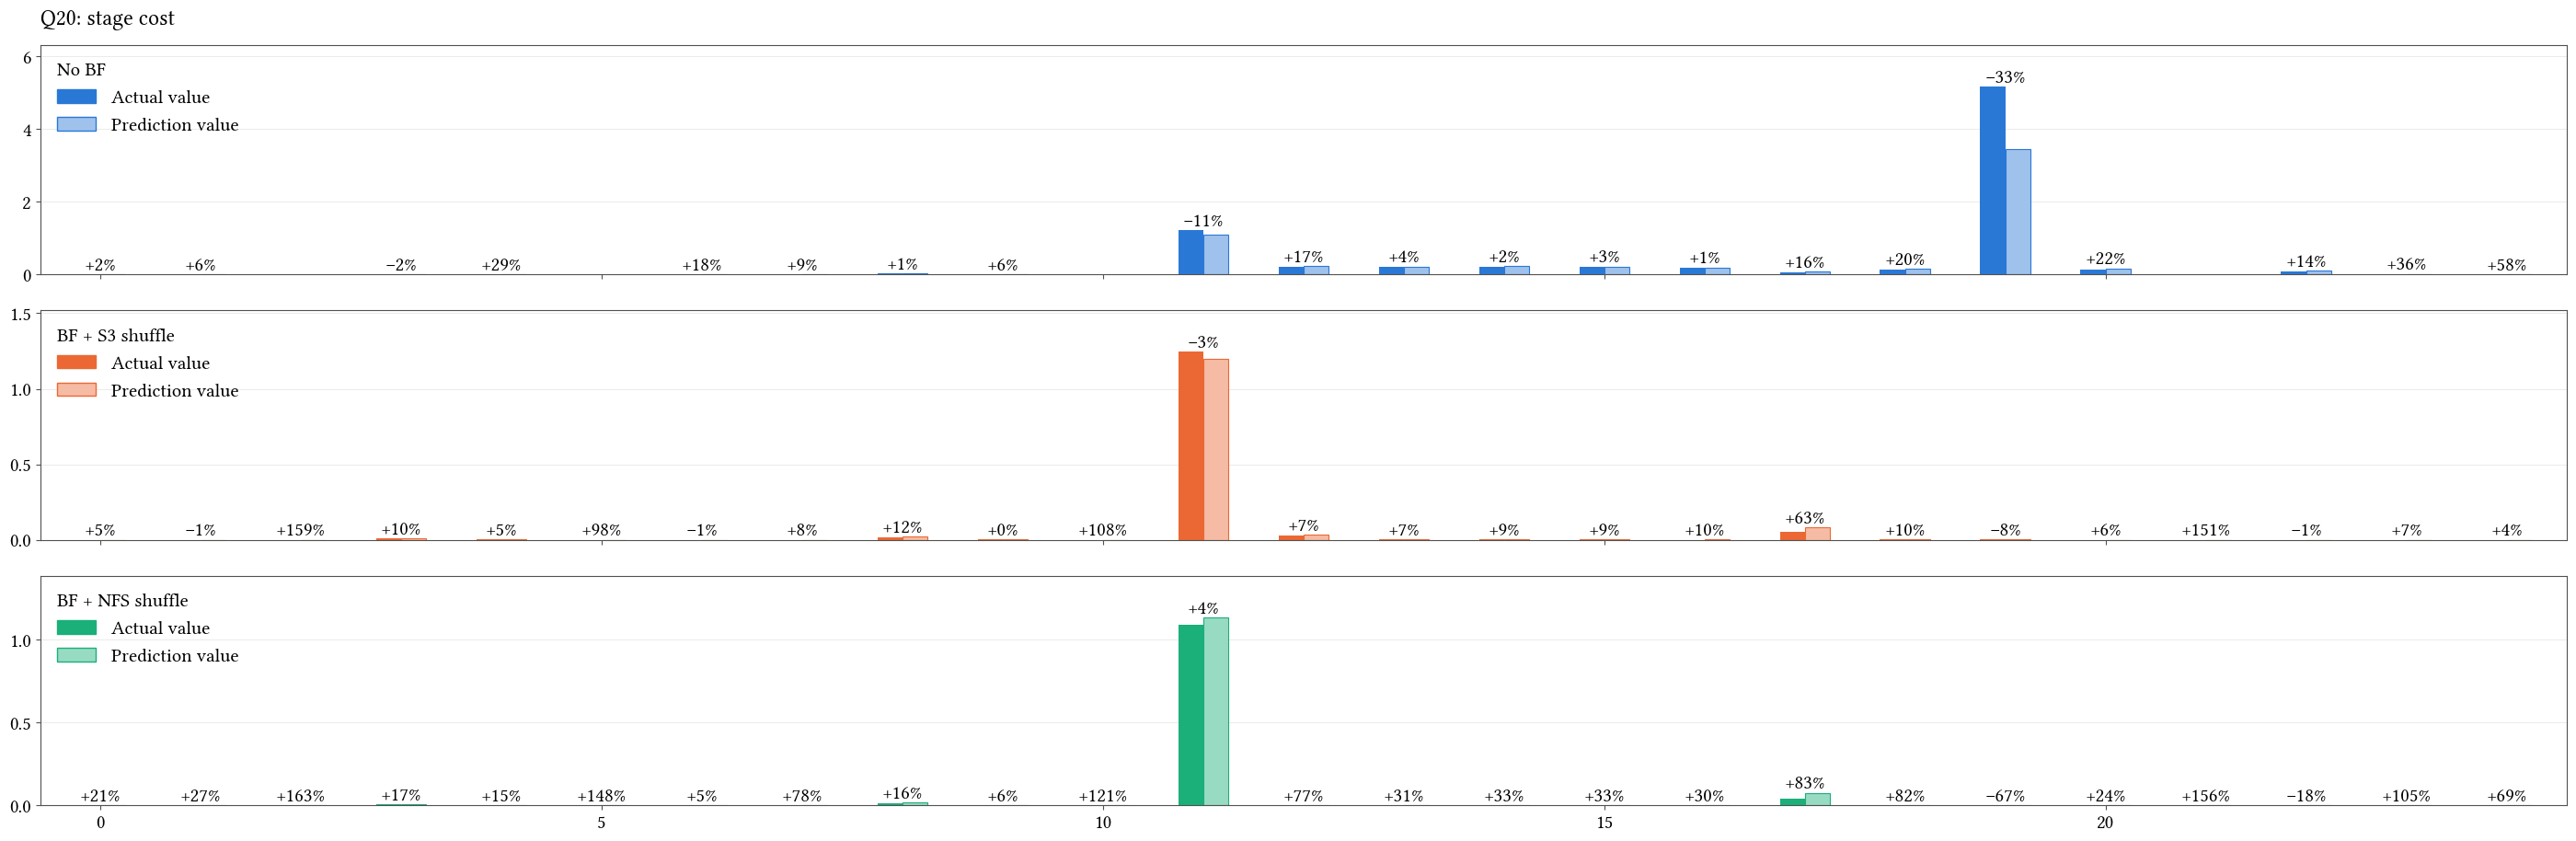

In [9]:
TITLE    = {"time": "{query}: stage time", "cost": "{query}: stage cost"}   # None để bỏ; {query} tự điền
YLABEL   = {"time": "Stage time (s)", "cost": f"Stage cost ({COST_UNIT})"}
LEGEND_LABELS = ("Actual value", "Prediction value")
XTICK_WRAP = 10                         # tên stage xuống dòng sau ~10 ký tự (0 = không xuống dòng)
XTICK_ROT = 0                           # góc xoay tên stage (0 khi đã xuống dòng; 45 nếu XTICK_WRAP = 0)
GROUP_GAP = 0.5                         # khoảng trống giữa các stage (0..1, càng lớn cột càng hẹp)
SHOW_ERR = True                         # ghi sai số (%) của model trên cột
MIN_ERR_LABEL = 0                       # 0 = ghi % cho mọi cột; > 0 thì bỏ nhãn cho stage nhỏ hơn ngưỡng (giây / đơn vị chi phí)
LEGEND_LOC = "upper left"              # vị trí legend trong mỗi panel: "upper left", "upper right", "center left", "best", …
SHARE_Y  = False                        # True = cùng thang Y giữa các hệ (so độ lớn trực tiếp)
FIGSIZE  = None                         # None = tự tính theo số stage và số hệ, hoặc ví dụ (16, 9)

COLUMNS = {"time": ("meas_d_wall", "model_d", 1), "cost": ("meas_C", "model_C", COST_SCALE)}

order = []                              # thứ tự stage theo pipeline, gộp từ các hệ (hệ BF có thêm merge BF)
for s in sorted(SYSTEMS, key=lambda s: -len(DATA[s][0])):
    for v in DATA[s][0]["stage"]:
        if v not in order:
            order.append(v)
n = len(order)

for metric, (c_meas, c_model, scale) in COLUMNS.items():
    fig, axes = plt.subplots(len(SYSTEMS), 1, figsize=FIGSIZE or (max(5, 1.05 * n + 2), 3 * len(SYSTEMS)),
                             sharex=True, sharey=SHARE_Y, squeeze=False)
    axes = axes[:, 0]
    w = (1 - GROUP_GAP) / 2
    for ax, s in zip(axes, SYSTEMS):
        st = DATA[s][0].set_index("stage")
        idx = [i for i, v in enumerate(order) if v in st.index]
        meas = [st.loc[order[i], c_meas] * scale for i in idx]
        model = [st.loc[order[i], c_model] * scale for i in idx]
        ax.bar([i - w / 2 for i in idx], meas, w, color=COLOR[s], zorder=2)
        ax.bar([i + w / 2 for i in idx], model, w, color=tint(COLOR[s]), edgecolor=COLOR[s], lw=0.8, zorder=2)
        if SHOW_ERR:
            for i, a, b in zip(idx, meas, model):
                if max(a, b) >= MIN_ERR_LABEL and a > 0:
                    ax.text(i, max(a, b), neg(f"{100 * (b / a - 1):+.0f}%"), ha="center", va="bottom", fontsize=FONT_SIZE, color=INK)
        #ax.set_ylabel(YLABEL[metric])
        if not SHARE_Y:
            ax.set_ylim(0, max(meas + model) * 1.22)
        ax.set_xlim(-0.6, n - 0.4)
        ax.grid(axis="x", visible=False)
        ax.legend(handles=[Patch(color=COLOR[s], label=LEGEND_LABELS[0]), Patch(facecolor=tint(COLOR[s]), edgecolor=COLOR[s], label=LEGEND_LABELS[1])], title=LABEL[s], alignment="left", loc=LEGEND_LOC, fontsize=FONT_SIZE, title_fontsize=FONT_SIZE)
    if SHARE_Y:
        axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.1)

   # axes[-1].set_xticks(range(n), xlabels(order), rotation=XTICK_ROT, ha="right" if XTICK_ROT else "center", rotation_mode="anchor", fontsize=FONT_SIZE)
    fig.tight_layout()
    if TITLE and TITLE.get(metric):
        top = axes[0].get_position().y1 + FONT_SIZE * 0.8 / 72 / fig.get_figheight()
        fig.text(axes[0].get_position().x0, top, TITLE[metric].format(query=QUERY.upper()),ha="left", va="bottom", fontsize=FONT_SIZE * 1.15, color=INK)
    save(fig, f"{QUERY}-stages-{metric}")
    plt.show()